# PIC 16A Group Project

#### By Liran Zhang and Ryan Vock
#### June 2nd, 2022

## Group Contribution Statement

Both of us wrote the code, comments, and analysis in all the following sections of the project. Ryan led Table 1, Figure 1, wrote explanations for the figures, and the Extra Trees Classifer Model. Liran led Figure 2 and 3, the K Neighbors Classifier Model, and the Random Forest Classifier Model. We checked each other’s work and made revisions to code and writing.

## Data Import and Cleaning

First, we turn off those pesky warnings.

In [8]:
import warnings
warnings.filterwarnings('ignore')

Now, we will import all necessary libraries and packages.

In [10]:
import pandas as pd
import pandas as pd
import numpy as np
import urllib
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from itertools import combinations
from sklearn.linear_model import LogisticRegression

Next, we import the penguin data and put it in a Pandas dataframe.

In [12]:
url = 'https://philchodrow.github.io/PIC16A/datasets/palmer_penguins.csv'
penguins = pd.read_csv(url) # create dataframe from data

penguins.head() # Show first 4 rows

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


We want to make some preliminary modifications to our entire dataset, such as removing a row that has an entry in the "Sex" column as a '.' character, as well as dropping the "Region" and "Stage" columns. "Region" and "Stage" can be removed because they contain the same information for all the penguins, so they are not helpful to our species predictions. Finally, we will simplify the names of the different Species.

In [14]:
penguins = penguins[penguins.Sex != '.']
penguins = penguins.drop(columns = ['Region', 'Stage']) # drop columns
penguins["Species"] = penguins["Species"].str.split().str.get(0) # simplify species names

We will also split our data into an 80/20% train-test-split to use later.

In [16]:
penguins_train, penguins_test = train_test_split(penguins, test_size = 0.2)

We will create a function that will do some automated cleaning tasks, which will be helpful when we split up our data later. This function will also split up the columns into X, the columns that will be used to predict Y, which will be the column that we want to predict.

In [18]:
def prep_penguins_data(data_df):
    """
    Cleans and separates given data for later use in model and function
    
    Parameters
    ----------
    data_df: dataframe, provided dataframe to clean
    
    Output
    ----------
    X: dataframe, dataframe without target column
    Y: dataframe, dataframe with only target column
    """
    df = data_df.copy() # make sure we don't make any permanent changes to larger dataframe
    df = df.dropna() # get rid of all NaN values in the columns that we send to the function
    le = preprocessing.LabelEncoder()
    
    df['Sex'] = le.fit_transform(df['Sex']) # encode Sex column 
    
    df['Island'] = le.fit_transform(df['Island']) # encode Island column
    
    df['Species'] = le.fit_transform(df['Species']) # encode Species column if included
    
    X = df.drop(['Species'], axis = 1) # split our predictor and target columns
    y = df['Species']
    
    return(X, y)

## Exploratory Analysis

### Table 1: Summary Statistics for Each Island

We will create a table containing summary statistics for the culmen length and culmen depth of the penguins, grouped by the island and species.

In [22]:
def penguin_summary_table(group_cols, value_cols):
    """
    Creates a dataframe with summary statistics of provided columns
    
    Parameters
    ----------
    group_cols: list, categories to group table by
    value_vols: list, quantitative columns to provide summary statistics for
    
    Output
    ----------
    descriptive_table: dataframe, table with summary statistics
    """
    descriptive_table = penguins.groupby(group_cols)[value_cols].describe() # create table
    return(descriptive_table)
    
    
penguin_summary_table(["Island", "Species"], ["Culmen Length (mm)", "Culmen Depth (mm)"])

Culmen Length (mm)                                     \
                                 count       mean       std   min     25%   
Island    Species                                                           
Biscoe    Adelie                  44.0  38.975000  2.480916  34.5  37.675   
          Gentoo                 122.0  47.529508  3.082386  40.9  45.325   
Dream     Adelie                  56.0  38.501786  2.465359  32.1  36.750   
          Chinstrap               68.0  48.833824  3.339256  40.9  46.350   
Torgersen Adelie                  51.0  38.950980  3.025318  33.5  36.650   

                                         Culmen Depth (mm)             \
                       50%     75%   max             count       mean   
Island    Species                                                       
Biscoe    Adelie     38.70  40.700  45.6              44.0  18.370455   
          Gentoo     47.30  49.575  59.6             122.0  14.976230   
Dream     Adelie     38.55  40.375  44.1              56.0  18.251786   
          Chinstrap  49.55  51.075  58.0              68.0  18.420588   
Torgersen Adelie     38.90  41.100  46.0              51.0  18.429412   

                                                                 
                          std   min    25%    50%     75%   max  
Island    Species                                                
Biscoe    Adelie     1.188820  16.0  17.65  18.45  19.025  21.1  
          Gentoo     0.983084  13.1  14.20  15.00  15.700  17.3  
Dream     Adelie     1.133617  15.5  17.50  18.40  18.825  21.2  
          Chinstrap  1.135395  16.4  17.50  18.45  19.400  20.8  
Torgersen Adelie     1.339447  15.9  17.35  18.40  19.250  21.5

This tells us a couple things. First, we notice that the Gentoo species is only present on Biscoe Island. Similarly, the Chinstrap species is only on Dream Island, and the only species on Torgersen is the Adelie. We also see that the Gentoo and Chinstrap penguins have a significantly greater culmen length when compared to the Adelie, on average. We also notice that the culmen depths are very similar, on average, throughout species and island excluding the Gentoo.

### Figure 1: Comparing Physical Characteristics of Penguins

We now create a multi-axis scatterplot to look at the differences in physical characteristics between different species of penguins, which include culmen length, culmen depth, and body mass.

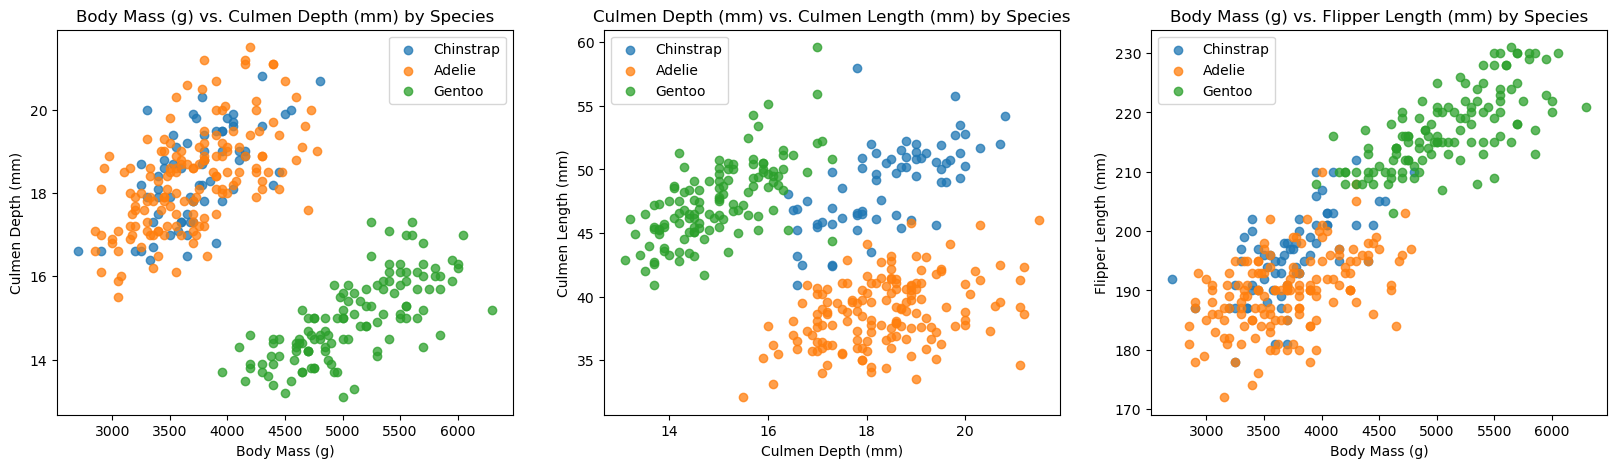

In [26]:
 # create subplots
species = set(penguins['Species']) # create set of Species

def create_scatter(cols):
    """
    Creates a series of scatterplots with given axes
    
    Parameters
    ----------
    cols: list of lists, axes to create scatterplots with
    
    Output
    ----------
    Series of scatterplots
    """
    
    fig, ax = plt.subplots(1, len(cols), figsize = (20, 5)) # create axes
    for i in range(len(cols)):
        ax[i].set(xlabel = cols[i][0], ylabel = cols[i][1]) # set labels

        for j in species: # graph scatterplots
            subspecies = penguins[penguins['Species'] == j] # define currect subspecies
            ax[i].scatter(subspecies[cols[i][0]], subspecies [cols[i][1]], label = j.split(' ')[0], alpha = 0.75)
    
        ax[i].legend() # create legend
        ax[i].set_title(cols[i][0] + " vs. " + cols[i][1] + " by Species")


create_scatter([["Body Mass (g)", "Culmen Depth (mm)"], ["Culmen Depth (mm)", "Culmen Length (mm)"], ["Body Mass (g)", "Flipper Length (mm)"]])



Here, we begin to see some grouping in the characteristics. In the first subplot, we see that the Adelie and Chinstrap penguins have very similar culmen depth to body mass ratios, but the Gentoo are isolated in this ratio. Next, we see that the culmen length to culmen length ratios are grouped fairly separately. This is a sign that this could be a good set of quantitative variables to use, since they are distinct in their groupings. Finally, we see that the body mass - flipper length ratios are grouped similarly to body mass - culmen depth, where two species are grouped together, with the third separated. Based on this figure alone, culmen depth and culmen length are good candidates for our predictor variables.

### Figure 2: Culmen Depth Box Plot by Island

We will create six box plots (for both sexes on all three islands), to consider the culmen depths within each category.

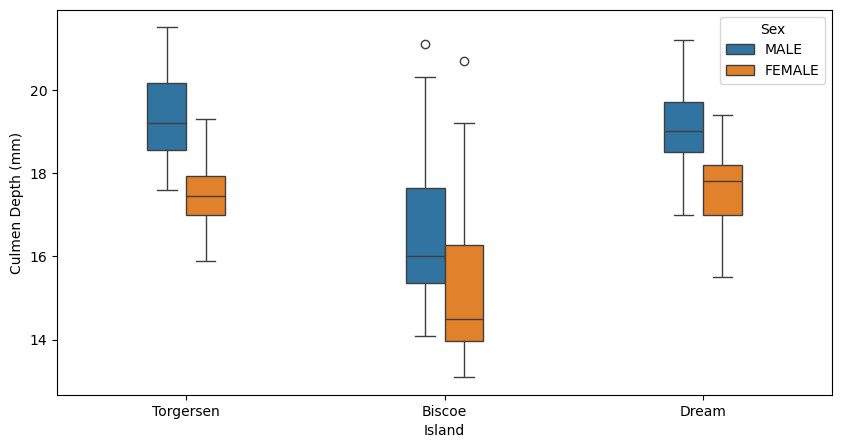

In [30]:
fig, ax = plt.subplots(1, figsize = (10, 5))
ax = sns.boxplot(x = "Island", y = "Culmen Depth (mm)", hue = "Sex", data = penguins, width = 0.3)

We see that Torgersen and Dream islands have a smaller range in culmen depth, for both sexes. We also see that for each island, the average culmen depths are very close between the male and female penguins, with the female penguins typically having a smaller average depth. Finally, Biscoe Island has a much lower average depth than the other two islands.

### Figure 3: Mean Body Mass per Species

We will now consider how body mass differs across penguin Species with use of a bar chart.

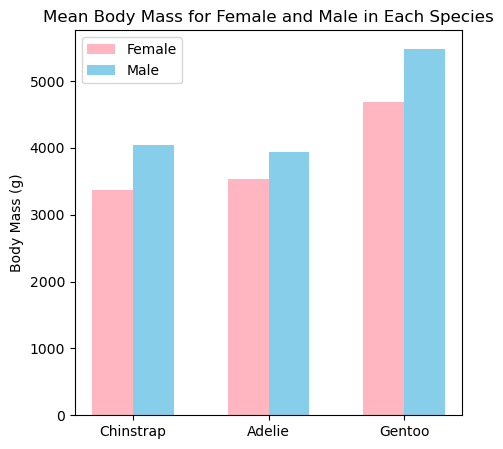

In [34]:
df_fg3 = penguins.groupby(["Species", "Sex"])["Body Mass (g)"].mean()

# set width of bar
barWidth = 0.3
fig = plt.subplots(figsize =(5, 5))
 
# set height of bar
female = [df_fg3[0], df_fg3[2], df_fg3[4]]
male = [df_fg3[1], df_fg3[3], df_fg3[5]]

X_axis = np.arange(len(species))
  
plt.bar(X_axis - 0.15, female, color ='lightpink', width = barWidth, label = 'Female')
plt.bar(X_axis + 0.15, male, color ='skyblue', width = barWidth, label = 'Male')
  
plt.xticks(X_axis, species)
plt.ylabel("Body Mass (g)")
plt.title("Mean Body Mass for Female and Male in Each Species")

plt.legend()


We notice that Gentoo penguins are by far the heaviest, with Adelie and Chinstraps being almost identically heavy, even between male and female penguins. This lack in differentiation means that body mass likely won't perform well in our model, making it a less favored contender for our model selection.

## Feature Selection

In this section, the goal is to choose 3 features, including 1 qualitative feature and 2 quantitative features, that can best predict species of penguins. 

The 3 features we chose are 
- "Sex"
- "Culmen Length (mm)"
- "Culmen Depth (mm)" 

The choice is based on both our exploratory analysis and automated feature selection.  

#### Explanation based on exploratory analysis:
For the quantitative features, our initial hypothesis is that culmen length and culmen depth will be the best quantitative features. As shown in the second scatterplot of Figure 1, when we plot culmen length and culmen depth and group by speices, scatters cluster together within each species and are distinct between species. This pattern suggests that our model will likely to have more accurate predictions of penguin species based on culmen length and culmen depth. This hypothesis is further supported by our automated feature selection (see below).  

For the qualitative feature, options are "Sex" and "Island." It is currently unclear which one is a better choice. Thus we will perform automated feature selection using cross validation to choose between the two and further test our findings from the previous section.

#### Explanation based on automated feature selection:
One preliminary step towards our automated feature selection is to get rid of columns for record purpose only, such as "Sample Number" and "Individual ID", which are obviously not helpful for predicting species. In doing so, we create "clean" versions of our training and testing sets so that they only include useful columns that our automated feature selection will focus on. 

Next, we call prep_penguins_data() on the clean datasets and seperate them into predictor (X) and target (y) variables. 

Then, we create a logistic regression module, search through all possible combinations of 3 features with the itertools module, and see which combination yields the best cross validation score. To avoid code duplication, we define a function to carry out this task. Note that for each combination, we want to include only one qualitative feature, so we separate out "Sex" and "Island" and append either of them to all combinations of 2 quantitative features.

Finally, we find that "Sex" is the better qualitative feature and, in line with our hypothesis based on exploratory analysis, "Culmen Length (mm)" and "Culmen Depth (mm)" are the two quantitative features to choose.

Below is the process of our automated feature selection.

We will first create a training and testing set of our data. To do so, we will first set the random seed to make sure our values are consistent.

In [39]:
np.random.seed(2022)

Now, in order to compute cross validation scores, we will limit our dataset into only the columns that we find helpful. We then split our training and testing data, that we will later use for cross-validation. Finally, we select our quantitative columns, which we will use subsets of to find the best score.

In [41]:
useful_cols = ["Species",
                "Sex",
                "Island",
                "Culmen Length (mm)", 
                "Culmen Depth (mm)", 
                "Flipper Length (mm)",
                "Body Mass (g)",
                "Delta 15 N (o/oo)",
                "Delta 13 C (o/oo)"] # Necessary columns for cross validation


train_clean = penguins_train[useful_cols] # clean our train-test-split
test_clean = penguins_test[useful_cols]

X_train, y_train = prep_penguins_data(train_clean) # create test, training df's
X_test,  y_test  = prep_penguins_data(test_clean)


quantitative_cols = ["Culmen Length (mm)", 
                    "Culmen Depth (mm)", 
                    "Flipper Length (mm)",
                    "Body Mass (g)",
                    "Delta 15 N (o/oo)",
                    "Delta 13 C (o/oo)"] # define the quantitative columns we will test with cross-validation

We define a function to test cross validation scores against all the quantitative columns for a given qualitative column.

In [43]:
def cross_val(model, qualitative_col):
    """
    Calculates highest cross validation score and correspoding quantitative columns given 
    a model and qualitative column
    
    Parameters
    ----------
    model: scikitlearn algorithm, to run cross validation scores on
    qualitative_col: string, qualitative column to test quantitative columns with
    
    Output
    ----------
    best_cv: double, best cross validation score across combinations
    best_cols: list, best quantitative columns providing the best CV score
    """
    # initialize best cv score and best columns to update later  
    best_cv = 0
    best_cols = None
    # iterate over all possible combinations of 2 quantitative columns 
    for cols in combinations(quantitative_cols, 2):
        cols_list = list(cols)
        # append the qualitative column to form a combination of 3 columns 
        cols_list.append(qualitative_col)

    ## Peform 10-fold Cross Validation 
    # for each combination of columns, compute the CV score
        cv = cross_val_score(model, X_train[cols_list], y_train, cv = 10).mean()
        # update best cv score and best columns 
        if cv > best_cv:
            best_cv = cv
            best_cols = cols
        
    return(best_cv, best_cols)

We now test the "Sex" column for the logistic regression model.

In [45]:
LR = LogisticRegression()
cross_val(LR, 'Sex')

(0.9883076923076924, ('Culmen Length (mm)', 'Culmen Depth (mm)'))

We notice that we get a very high cross validation score of 0.998 with this combination.

We will also consider "Island", our only other qualitative column.

In [48]:
LR = LogisticRegression()
cross_val(LR, 'Island')

(0.9650769230769229, ('Culmen Length (mm)', 'Culmen Depth (mm)'))

This combination also provides a high cross validation score of 0.981, though slightly lower than with the "Sex" column.

Here, we see that our best combinations of features, at least for the logistic regression model, arrives via the use of the "Sex" column, combined with "Culmen Length" and "Culmen Depth".

Based on the automated feature selection and the findings from the exploratory analysis section, we will define our three most successful features that we will now test with our models.

In [52]:
three_features = ["Sex", "Culmen Length (mm)", "Culmen Depth (mm)"]
X_train = X_train[three_features] # alter X_train, X_test to feature these 3 features
X_test = X_test[three_features]

## Modeling

We will now use three different models (Extra Trees Classifier, Random Forest Classifer, and K Neighbors Classifier) and evaluate their performance.

First, we create the mylabels variable, which will be helpful when we create the legends for the scatterplots in our decision regions.

In [56]:
mylabels = list(set(penguins['Species'])) # create list of labels for legend

Next, we define our function that will plot decision regions for the Culmen Length and Culmen Depth variables, for each Male and Female penguins. This will show how our models view our data.

In [58]:
# Define a function to plot decision regions 
def plot_regions(c, X_t, y_t):
    """
    Plots decision regions for each value of 'Sex' column
    
    Parameters
    ----------
    c: model, given model to create decision region for
    
    Output
    ----------
    Set of decision regions for each value
    """
        
    # for convenience, give names to the two 
    # columns of the data
    dict_sex = {0:"Male", 1:"Female"}
    fig, ax = plt.subplots(1,2, figsize = (12,6))
    X_fresh = X_t
    y_fresh = y_t # make sure not to pollute our data set!
    
    for i in dict_sex.keys():
        X_plot = X_fresh.copy() # create copy of X
        y_plot = y_fresh.copy() # create copy of Y
        X_plot['Species'] = y_plot # group X, Y together so that we can create a subset for a single sex
        X_plot =  X_plot[X_plot["Sex"] == i] # create subset of current sex
        x0 = X_plot['Culmen Length (mm)']
        x1 = X_plot["Culmen Depth (mm)"]
        y_plot = X_plot['Species'] # retrieve our species, grouped by current sex
        X_plot = X_plot.drop(['Species'], axis = 1) # drop target column from X
        
        # generate synthetic data based on x0 and x1
        grid_x = np.linspace(x0.min(),x0.max(),501)
        grid_y = np.linspace(x1.min(),x1.max(),501)
        xx, yy = np.meshgrid(grid_x, grid_y)

        XX = xx.ravel()
        YY = yy.ravel()

        n = XX.shape
        
        # include Sex variable into the data 
        # for male, add a column of zeros
        if i == 0:
            XY = np.c_[np.zeros(n), XX, YY]
        # for female, add a column of ones 
        else:
            XY = np.c_[np.ones(n), XX, YY]
            
        # make predictions on the synthetic data XY 
        p = c.predict(XY)
        p = p.reshape(xx.shape)


        # use contour plot to visualize the predictions
        ax[i].contourf(xx, yy, p, cmap = "jet", alpha = 0.2)

        # plot the real data
        scatter = ax[i].scatter(x0, x1, c = y_plot, cmap = "jet", vmin = 0, vmax = 2)

        
        # set labels, title, and legend appropriately 
        ax[i].set(xlabel = 'Culmen Length (mm)', 
               ylabel = "Culmen Depth (mm)",
               title = dict_sex[i])
        ax[i].legend(handles=scatter.legend_elements()[0], labels = mylabels)

Next, we will introduce our first model, the Extra Trees Classifier.

### Model 1: Extra Trees Classifier

#### 1.1 How the model works
Our first model is an Extra Trees Classifier. This model works by fitting randomized tree classifiers on various sub-samples of our penguins data and predict penguins' species. It uses averaging to improve accuracy of its predictions and control overfitting. 

#### 1.2 Cross validation to select a candidate model
We want to know the optimal depth to base our model upon, so we will test the given cross validation score across a range of depths, from 1 to 15. Whichever depth gives us the best cross validation score will be used to test against unseen data, including our confusion matrix and our decision regions.

7

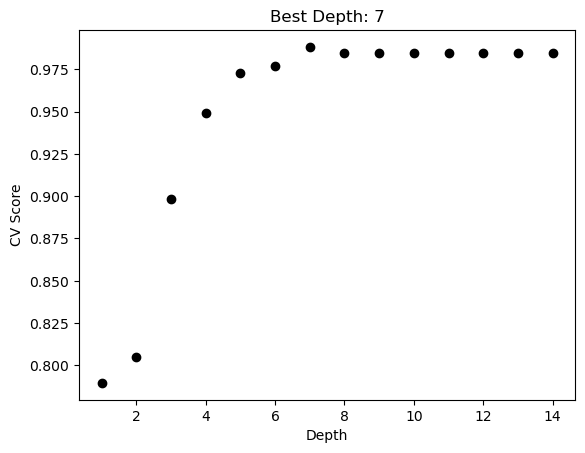

In [63]:
fig, ax = plt.subplots(1)

best_score = 0

for d in range(1, 15): # test 15 different depths
    etc = ExtraTreesClassifier(max_depth = d)
    cv_score = cross_val_score(etc, X_train, y_train, cv = 10).mean()
    ax.scatter(d, cv_score, color = "black")
    if cv_score > best_score:
        best_depth = d # update best depth
        best_score = cv_score # update best score
        
l = ax.set(title = "Best Depth: " + str(best_depth), xlabel = "Depth", ylabel = "CV Score")
best_depth

We achieve an optimal depth of 7.

#### 1.3 Train the model on data

In [66]:
etc = ExtraTreesClassifier(max_depth = best_depth)
etc.fit(X_train, y_train)
etc.score(X_test, y_test)

0.9850746268656716

The ETC model gives us a score of ~0.984.

#### 1.4 Evaluate model performance
We will now test our model with unseen data, using our optimal depth as found above.

In [69]:
y_pred = etc.predict(X_test)
conf = confusion_matrix(y_test, y_pred)

y_pred, conf

(array([0, 0, 1, 0, 2, 0, 0, 1, 2, 0, 1, 0, 2, 1, 0, 2, 0, 0, 1, 2, 0, 1,
        0, 0, 0, 1, 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 2, 2, 2, 0, 2, 1, 2,
        2, 1, 2, 1, 2, 2, 0, 2, 1, 0, 2, 0, 2, 2, 0, 0, 1, 1, 0, 1, 1, 0,
        2]),
 array([[30,  1,  0],
        [ 0, 14,  0],
        [ 0,  0, 22]]))

From the confusion matrix, we notice that the [1][0] entry means that the model miscategorized a Gentoo as a Chinstrap.

Now, we will look at the decision regions for the ETC model.

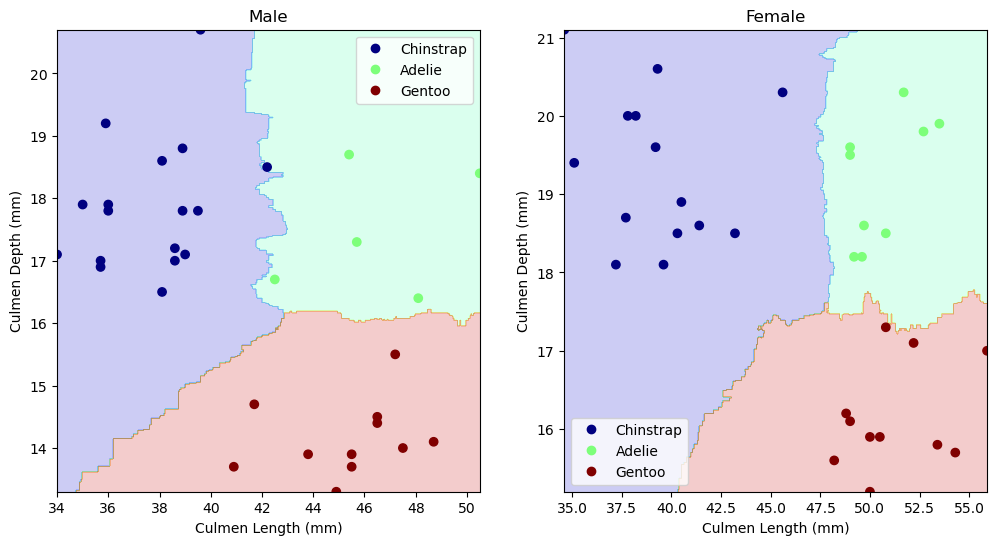

In [72]:
plot_regions(etc, X_test, y_test)

Here, we see that the model captures all of the penguins as the correct species, except for a single Male Gentoo that is classified as a Chinstrap. This is likely because the Gentoo lies on the outer edge of Culmen Length - Culmen Depth group for its species.

### Model 2: Random Forest Classifier

#### 2.1 How the model works
Our next model is a Random Forest Classifier. Similar to the extra trees classifier, this model works by drawing sub-samples of penguins data and fitting a decision tree classifier to each sample. Then it performs a vote for each prediction and selects the one with the most votes as the final prediction of a penguin's species. The model uses averaging to improve accuracy of its predictions and control overfitting. 

#### 2.2 Cross validation to select a candidate model
We want to know the optimal depth to base our model upon, so we will test the given cross validation score across a range of depths, from 1 to 15. Whichever depth gives us the best cross validation score will be used to test against unseen data, including our confusion matrix and our decision regions.

5

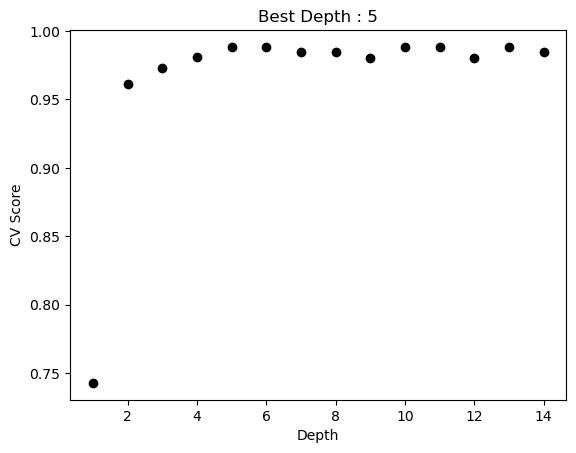

In [77]:
fig, ax = plt.subplots(1)

best_score = 0

for d in range(1,15): # test 15 different depths
    RF = RandomForestClassifier(max_depth = d)
    cv_score = cross_val_score(RF, X_train, y_train, cv = 10).mean()
    ax.scatter(d, cv_score, color = "black")
    if cv_score > best_score:
        best_depth = d # update best depth
        best_score = cv_score # update best CV score
        
l = ax.set(title = "Best Depth : " + str(best_depth),
       xlabel = "Depth", 
       ylabel = "CV Score")

best_depth

We achieve an optimal depth of 4.

#### 2.3 Train the model on data

In [80]:
# instantiate a model with the optimal model complexity found through the 10-fold cross validation
RF = RandomForestClassifier(max_depth = best_depth)

# fit the model using the entire training dataset 
RF.fit(X_train, y_train)

# test the model --> testing score 
# the testing data is "unseen" data, not touched until this point 
RF.score(X_test, y_test)

0.9850746268656716

The RF model with our found depth gives us a score of ~0.984.

#### 2.4 Evaluate model performance
We will now test our model with unseen data, using our optimal depth as found above.

In [83]:
y_pred = RF.predict(X_test)

confusion = confusion_matrix(y_test, y_pred)
y_pred, confusion

(array([0, 0, 1, 0, 2, 0, 0, 1, 2, 0, 1, 0, 2, 1, 0, 2, 0, 0, 1, 2, 0, 1,
        0, 0, 0, 1, 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 2, 2, 2, 0, 2, 1, 2,
        2, 1, 2, 1, 2, 2, 0, 2, 1, 0, 2, 0, 2, 2, 0, 0, 1, 1, 0, 1, 1, 0,
        2]),
 array([[30,  1,  0],
        [ 0, 14,  0],
        [ 0,  0, 22]]))

From the confusion matrix, we notice that the [0][1] entry across the diagonal shows that the model incorrectly categorizes a Chinstrap as a Gentoo.

Now, we will look at the decision regions for the RFC model.

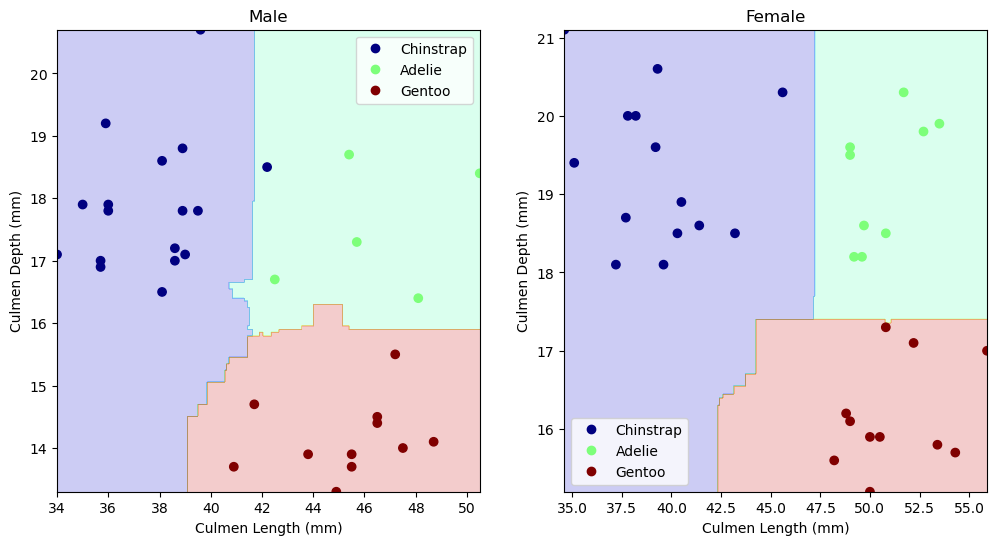

In [86]:
plot_regions(RF, X_test, y_test)

Here, we see that the model correctly categorizes all penguins except for a single Female Chinstrap, which the model classifies as a Gentoo. Again, the penguin lies on the outer edge of the ratio of quantitative variables for its species, thus causing the miscategorization by the model.

### Model 3: K Neighbors Classifier

#### 3.1 How the model works
Our next model is a K Neighbors Classifier. This model predicts penguins' species based on the k nearest neighbors. It performs the k-nearest neighbors vote, the prediction with the most votes will be the final prediction of a penguin's species. 

#### 3.2 Cross validation to select a candidate model
We want to know the optimal depth to base our model upon, so we will test the given cross validation score across a range of depths, from 1 to 15. Whichever depth gives us the best cross validation score will be used to test against unseen data, including our confusion matrix and our decision regions.

1

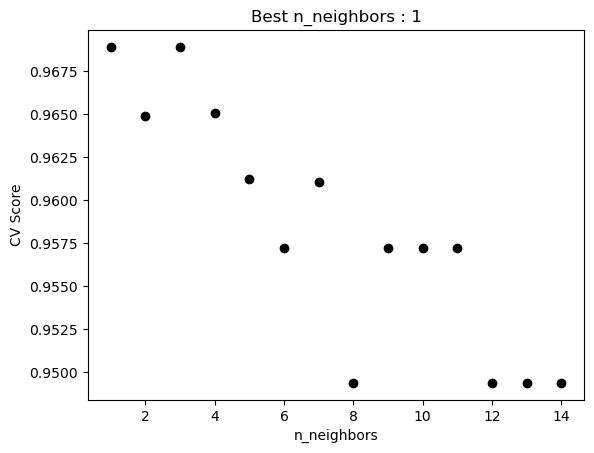

In [91]:
fig, ax = plt.subplots(1)

best_score = 0

for d in range(1,15): # test 15 different neighbor ranges
    KN = KNeighborsClassifier(n_neighbors = d)
    cv_score = cross_val_score(KN, X_train, y_train, cv = 10).mean()
    ax.scatter(d, cv_score, color = "black")
    if cv_score > best_score:
        best_n_neighbors = d # update best neighbor depth
        best_score = cv_score # update best CV score
        
l = ax.set(title = "Best n_neighbors : " + str(best_n_neighbors),
       xlabel = "n_neighbors", 
       ylabel = "CV Score")

best_n_neighbors

We find that the optimal number of neighbors is 1.

#### 3.3 Train the model on data

In [94]:
# instantiate a model with the optimal model complexity found through the 10-fold cross validation
KN = KNeighborsClassifier(n_neighbors = best_n_neighbors)

# fit the model using the entire training dataset 
KN.fit(X_train, y_train)

# test the model --> testing score 
# the testing data is "unseen" data, not touched until this point 
KN.score(X_test, y_test)

1.0

The K Neighbors Classifier model gives us a score of ~0.952.

#### 3.4 Evaluate model performance
We will now test our model with unseen data, using our optimal depth as found above.

In [97]:
y_pred = KN.predict(X_test)

confusion = confusion_matrix(y_test, y_pred)

y_pred, confusion

(array([0, 0, 1, 0, 2, 0, 0, 1, 2, 0, 1, 0, 2, 1, 0, 2, 0, 0, 1, 2, 0, 1,
        0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 2, 2, 2, 0, 2, 1, 2,
        2, 1, 2, 1, 2, 2, 0, 2, 1, 0, 2, 0, 2, 2, 0, 0, 1, 1, 0, 1, 1, 0,
        2]),
 array([[31,  0,  0],
        [ 0, 14,  0],
        [ 0,  0, 22]]))

From the confusion matrix, we notice that the [0][1] entry across the diagonal shows that the model incorrectly categorizes a Chinstrap as a Gentoo, the [0][2] entry shows the model incorrectly categorizes a Chinstrap as an Adelie, and the [1][0] entry shows the model incorrectly categorizes a Gentoo as a Chinstrap.

Now, we will look at the decision regions for the KN model.

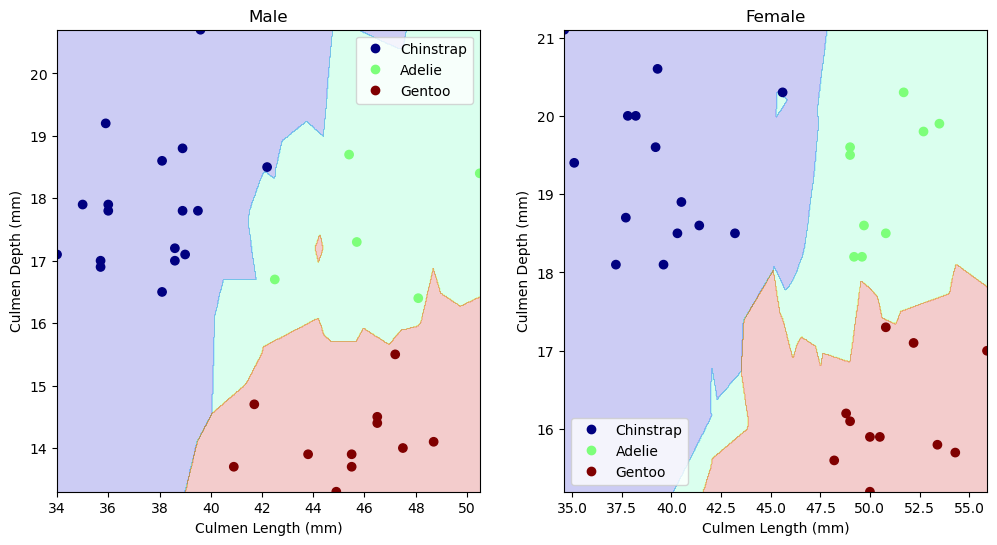

In [100]:
plot_regions(KN, X_test, y_test)

Here, we see that the model does a very good job of isolating each species. As shown by the confusion matrix, two Female Chinstraps are miscategorized, one as a Gentoo and one as an Adelie. Furthermore, one Male Gentoo is miscategorized as a Chinstrap. 

## Discussion

To conclude, we have chosen Culmen Length and Culmen Depth as our two quantitative features. We have chosen Sex as our one qualitative feature. Using these features, we tested 3 different models, Extra Trees Classifier, Random Forest Classifier, and K Neighbors Classifier. As seen from our decision regions, each model performed quite well in predicting unseen data. All in all, Extra Trees Classifier and Random Forest Classifier each miscategorized only 1 penguin, each with an accuracy score of 0.984. K Neighbors Classifier miscategorized 3 penguins, with a score of 0.952. Since the Random Forest Classifier tied for the best score and used a depth of 4, while Extra Trees Classifier used a depth of 7, we choose the Random Forest Classifier as our ideal model.

If we had more data and could use more features, our models could do an even better job. If we could have combined even more qualitative and quantitative features, our models could be more accurate on large data sets.